In [25]:
import numpy as np
import pandas as pd
import re

In [26]:
df=pd.read_csv('bbc_news.csv')

In [27]:
#----------------data understanding----------------

In [28]:
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42115 entries, 0 to 42114
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        42115 non-null  object
 1   pubDate      42115 non-null  object
 2   guid         42115 non-null  object
 3   link         42115 non-null  object
 4   description  42115 non-null  object
dtypes: object(5)
memory usage: 1.6+ MB


In [30]:
df.isnull().sum()

title          0
pubDate        0
guid           0
link           0
description    0
dtype: int64

In [31]:
df.describe()

,title,pubDate,guid,link,description
count,42115,42115,42115,42115,42115
unique,39653,40189,39203,37856,38731
top,Election poll tracker: How do the parties comp...,"Tue, 20 Aug 2024 11:35:33 GMT",https://www.bbc.co.uk/news/business-61634959,https://www.bbc.co.uk/news/business-61634959?a...,How closely have you been paying attention to ...
freq,34,14,63,61,80


In [32]:
#-----------------text cleaning-------------------------

In [33]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r"[^a-zA-Z# ]","",text)
    return text

In [34]:
df['title']=df['title'].apply(clean_text)

In [35]:
df['description']=df['description'].apply(clean_text)

In [36]:
df.head()

,title,pubDate,guid,link,description
0,ukraine angry zelensky vows to punish russian ...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,the ukrainian president says the country will ...
1,war in ukraine taking cover in a town under at...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,jeremy bowen was on the frontline in irpin as ...
2,ukraine war catastrophic for global food,"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,one of the worlds biggest fertiliser firms say...
3,manchester arena bombing saffie roussoss paren...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,the parents of the manchester arena bombings y...
4,ukraine conflict oil price soars to highest le...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,consumers are feeling the impact of higher ene...


In [37]:
#---------------stemming-----------------------

In [38]:
!pip install gensim


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from gensim.parsing.preprocessing import STOPWORDS
from nltk.stem import PorterStemmer
from gensim import corpora
from gensim.models import LdaModel

In [40]:
stemmer=PorterStemmer()

In [41]:
df['tokens']=df['title'].apply(
    lambda x:[
        stemmer.stem(word)
        for word in x.split()
        if word not in STOPWORDS
    ]
)

In [42]:
dictionary=corpora.Dictionary(df['tokens'])

In [43]:
corpus=[dictionary.doc2bow(text) for text in df['tokens']]

In [20]:
#---------------apply lda------------------------

In [44]:
lda_model=LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    passes=10
)

In [45]:
for topic in lda_model.print_topics():
    print(topic)

(0, '0.010*"kill" + 0.009*"attack" + 0.008*"woman" + 0.008*"gaza" + 0.008*"man" + 0.008*"polic" + 0.008*"ukrain" + 0.008*"die" + 0.007*"israel" + 0.007*"war"')
(1, '0.011*"say" + 0.010*"uk" + 0.010*"elect" + 0.006*"life" + 0.006*"year" + 0.005*"labour" + 0.005*"new" + 0.005*"rise" + 0.005*"chang" + 0.005*"warn"')
(2, '0.015*"win" + 0.015*"england" + 0.011*"trump" + 0.011*"world" + 0.009*"man" + 0.008*"cup" + 0.007*"citi" + 0.007*"women" + 0.006*"final" + 0.006*"beat"')


In [46]:
df['tokens']

0        [ukrain, angri, zelenski, vow, punish, russian...
1                 [war, ukrain, take, cover, town, attack]
2                  [ukrain, war, catastroph, global, food]
3        [manchest, arena, bomb, saffi, roussoss, paren...
4        [ukrain, conflict, oil, price, soar, highest, ...
                               ...                        
42110                   [highlight, wale, histori, dublin]
42111                 [gang, jail, m, cocain, banana, box]
42112     [scottish, budget, present, huge, challeng, snp]
42113               [celebr, wale, histori, qualifi, euro]
42114                   [school, tell, muslim, girl, safe]
Name: tokens, Length: 42115, dtype: object

In [47]:
import pandas as pd

topics = lda_model.show_topics(num_topics=3, num_words=10, formatted=False)

data = []
for topic_no, words in topics:
    for word, weight in words:
        data.append([topic_no, word, weight])

df_topics = pd.DataFrame(data, columns=["Topic", "Word", "Weight"])
print(df_topics.head())

   Topic    Word    Weight
0      0    kill  0.009966
1      0  attack  0.008692
2      0   woman  0.008415
3      0    gaza  0.008400
4      0     man  0.008166


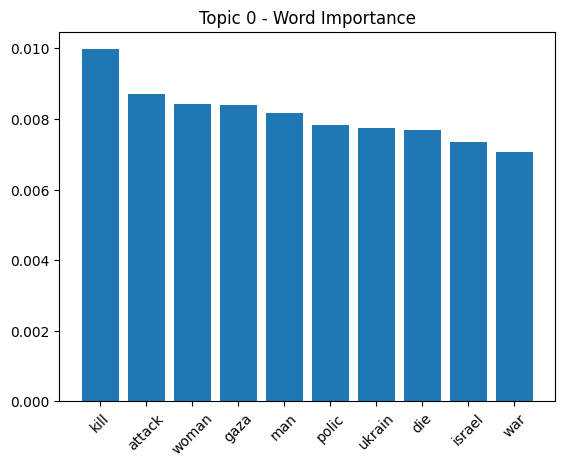

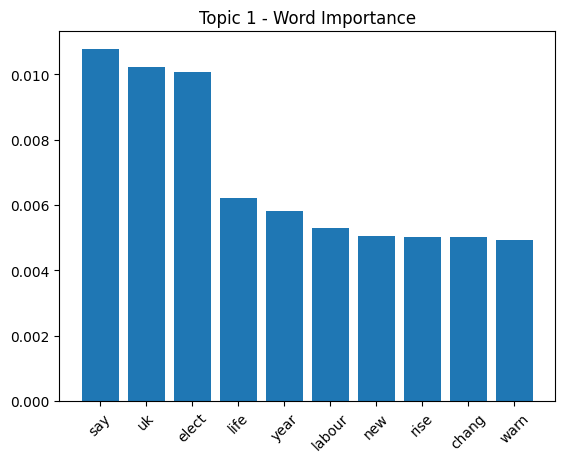

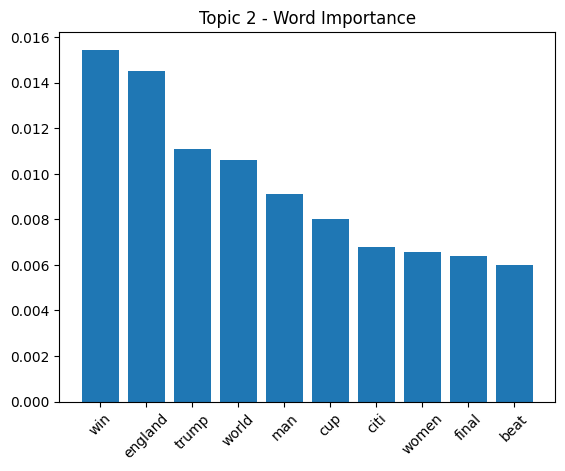

In [48]:
import matplotlib.pyplot as plt

for topic in df_topics['Topic'].unique():
    temp = df_topics[df_topics['Topic'] == topic]
    
    plt.figure()
    plt.bar(temp['Word'], temp['Weight'])
    plt.title(f"Topic {topic} - Word Importance")
    plt.xticks(rotation=45)
    plt.show()

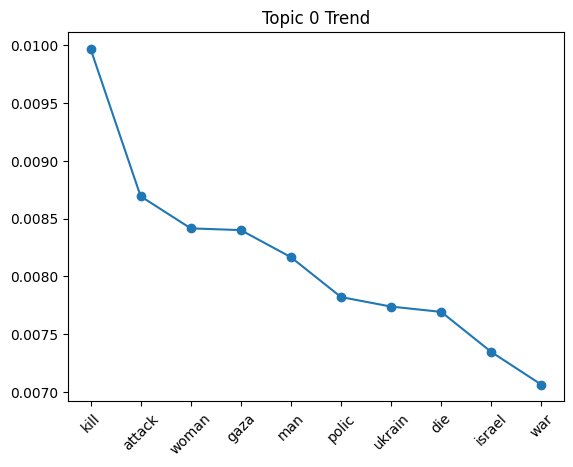

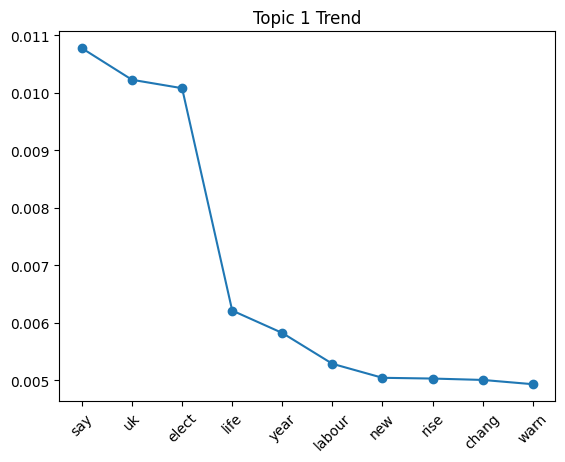

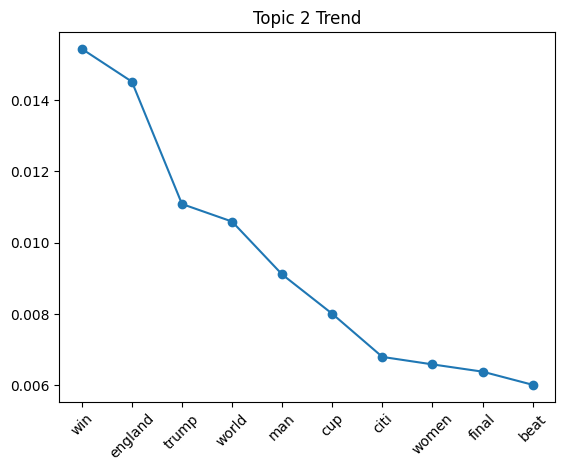

In [49]:
for topic in df_topics['Topic'].unique():
    temp = df_topics[df_topics['Topic'] == topic]
    
    plt.figure()
    plt.plot(temp['Word'], temp['Weight'], marker='o')
    plt.title(f"Topic {topic} Trend")
    plt.xticks(rotation=45)
    plt.show()

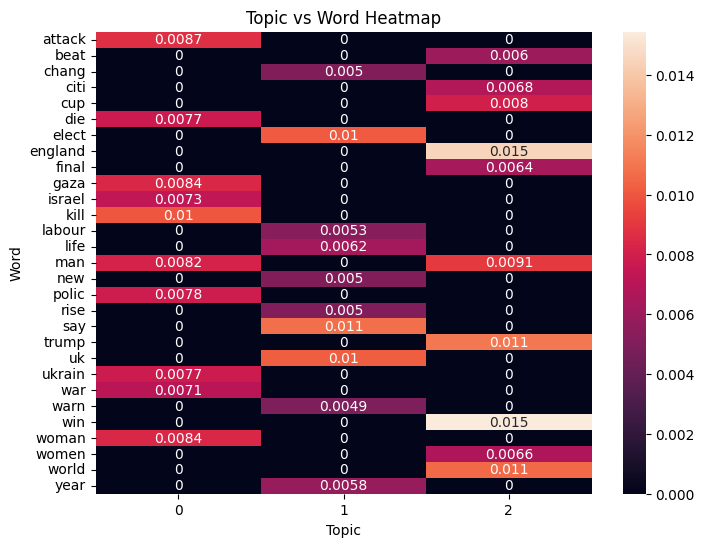

In [50]:
import seaborn as sns

pivot = df_topics.pivot(index="Word", columns="Topic", values="Weight").fillna(0)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True)
plt.title("Topic vs Word Heatmap")
plt.show()

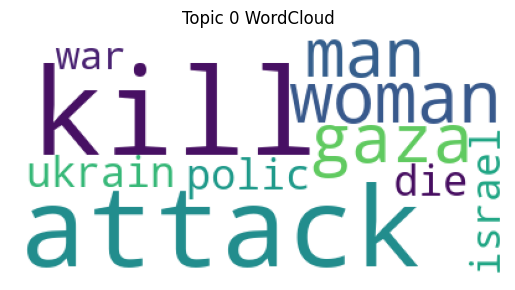

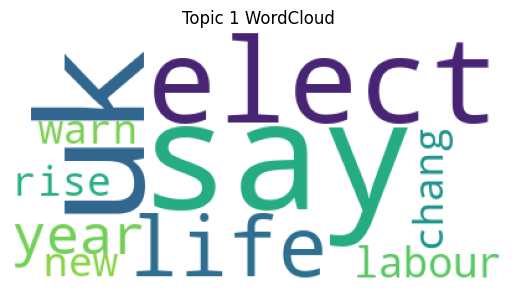

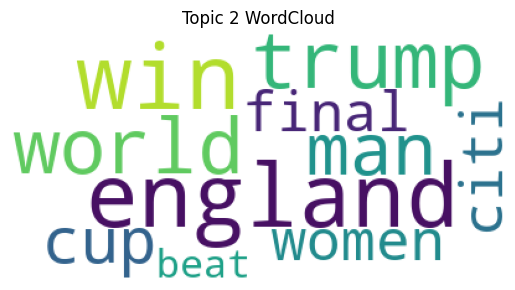

In [53]:
from wordcloud import WordCloud

for topic in df_topics['Topic'].unique():
    temp = df_topics[df_topics['Topic'] == topic]
    
    word_dict = dict(zip(temp['Word'], temp['Weight']))
    
    wc = WordCloud(background_color='white').generate_from_frequencies(word_dict)
    
    plt.figure()
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"Topic {topic} WordCloud")
    plt.show()

In [52]:
!pip install WordCloud


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
